In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

df_geolife = pd.read_csv(f'./data/Geolife/20260720_geolife_database_metrics.csv')
df_rmove = pd.read_csv(f'./data/rMove/20260720_rmove_database_metrics.csv')

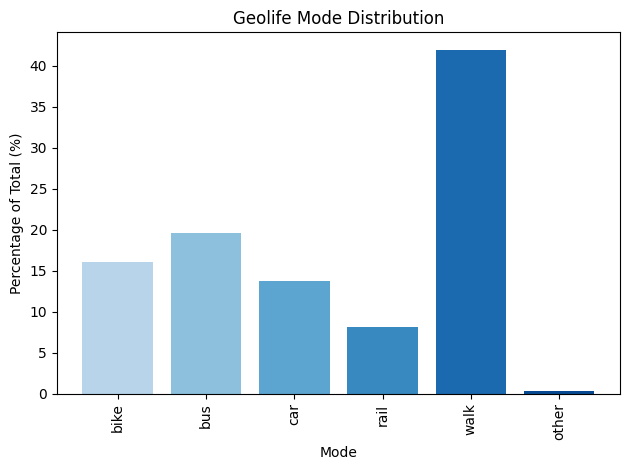

In [2]:
# Look at distributions of actual travel mode across time, distance, density, sparsity

fig, ax = plt.subplots()

# Gives percentages of each mode
counts_per_mode = df_geolife['actual_mode'].value_counts(normalize=True)

# counts_per_mode = counts_per_mode[counts_per_mode.index.isin(modes_to_include)]
# counts_per_mode['mode'] = counts_per_mode['mode'].map(lambda x: x if x in modes_to_include else 'other')

# Combine similar modes
counts_per_mode['car'] = counts_per_mode['car'] + counts_per_mode['taxi']
counts_per_mode = counts_per_mode.drop(['taxi'])
counts_per_mode['rail'] = counts_per_mode['subway'] + counts_per_mode['train']
counts_per_mode = counts_per_mode.drop(['subway', 'train'])

# Filter to only desired modes
modes_to_include = ['bike', 'bus', 'car', 'rail', 'walk']
counts_per_mode['other'] = counts_per_mode[~counts_per_mode.index.isin(modes_to_include)].sum()
counts_per_mode = counts_per_mode[counts_per_mode.index.isin(modes_to_include + ['other'])]

counts_per_mode = counts_per_mode.sort_index()
other = counts_per_mode.pop('other')
counts_per_mode = pd.concat([counts_per_mode, pd.Series({'other': other})])

# Graph
# ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.tab20.colors[:len(counts_per_mode)])
ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.Blues(np.linspace(0.3, 0.9, len(counts_per_mode))))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, symbol=None, decimals=0))
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Mode')
ax.set_ylabel('Percentage of Total (%)')
ax.set_title('Geolife Mode Distribution')
fig.tight_layout()

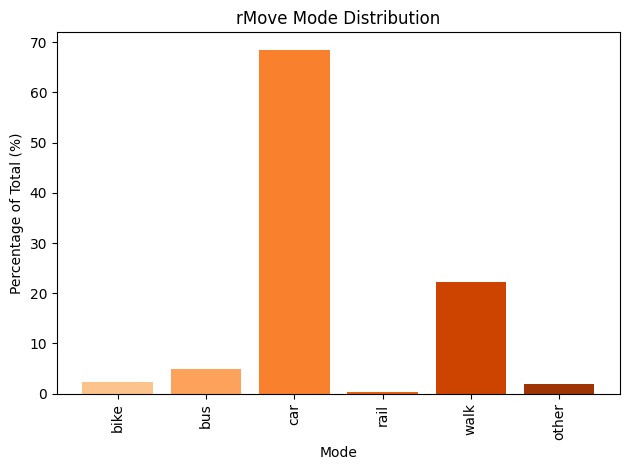

In [3]:
# Look at distributions of actual travel mode across time, distance, density, sparsity
from src.map_terminology import map_rmove_to_generic_mode

fig, ax = plt.subplots()

# Gives percentages of each mode
df_rmove['actual_mode'] = df_rmove['actual_mode'].map(map_rmove_to_generic_mode)
counts_per_mode = df_rmove['actual_mode'].value_counts(normalize=True)

counts_per_mode = counts_per_mode.sort_index()

# Filter to only desired modes
modes_to_include = ['bike', 'bus', 'car', 'rail', 'walk']
counts_per_mode['other'] = counts_per_mode[~counts_per_mode.index.isin(modes_to_include)].sum()
counts_per_mode = counts_per_mode[counts_per_mode.index.isin(modes_to_include + ['other'])]

other = counts_per_mode.pop('other')
counts_per_mode = pd.concat([counts_per_mode, pd.Series({'other': other})])

# Combine similar modes
# counts_per_mode['car / taxi'] = counts_per_mode['car'] + counts_per_mode['taxi']
# counts_per_mode = counts_per_mode.drop(['car', 'taxi'])
# counts_per_mode['subway / train'] = counts_per_mode['subway'] + counts_per_mode['train']
# counts_per_mode = counts_per_mode.drop(['subway', 'train'])
# counts_per_mode = counts_per_mode.sort_index()

# Graph
# ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.tab20.colors[:len(counts_per_mode)])
ax.bar(counts_per_mode.index, counts_per_mode.values, color=plt.cm.Oranges(np.linspace(0.3, 0.9, len(counts_per_mode))))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, symbol=None, decimals=0))
ax.tick_params(axis='x', labelrotation=90)
ax.set_xlabel('Mode')
ax.set_ylabel('Percentage of Total (%)')
ax.set_title('rMove Mode Distribution')
fig.tight_layout()

In [4]:
print(map_rmove_to_generic_mode("skateboard or rollerblade"))

other
